<a href="https://colab.research.google.com/github/nickplas/Intro_to_ML_25-26/blob/main/notebooks/Lab-7.KNNGaussianNaiveBayesTrees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification with KNN, Trees and Gaussian Naive Bayes

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy.spatial.distance import euclidean
from sklearn.metrics import euclidean_distances
from sklearn.metrics.cluster import entropy






Load and split the data from the Unsupervise Learning Dataset (Lab 5, Dry Bean Dataset):

In [30]:
FFILE = './Dry_Bean_Dataset.xlsx'
if os.path.isfile(FFILE): 
    print("File already exists")
    if os.access(FFILE, os.R_OK):
        print ("File is readable")
    else:
        print ("File is not readable, removing it and downloading again")
        !rm FFILE
        !wget "https://raw.github.com/alexdepremia/ML_IADA_UTs/main/Lab5/Dry_Bean_Dataset.xlsx"
else:
    print("Either the file is missing or not readable, download it")
    !wget "https://raw.github.com/alexdepremia/ML_IADA_UTs/main/Lab5/Dry_Bean_Dataset.xlsx"

File already exists
File is readable


In [31]:
# Load the data
data = pd.read_excel('./Dry_Bean_Dataset.xlsx')
data

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


Divide features and label. Split the data in train and test set and **after that** normalize them:

In [32]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing


X = data.iloc[:,:-1].values
label = data.iloc[:,16].values
colum_names = data.columns 

# Rescaling the features of the data to handle different units: subtracting the mean and dividing by the standard deviation
scaler = preprocessing.StandardScaler().fit(X)

# Transforming the original data using the calculated mean and standard deviation
X_scaled = scaler.transform(X)

# Creating an ordinal encoder for the ground truth labels
ordinal_encoder = preprocessing.OrdinalEncoder()

# Fitting the encoder to the label data
ordinal_encoder.fit(label.reshape(-1, 1))

# Transforming the original labels into encoded forms
y = ordinal_encoder.transform(label.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=0, stratify= y)

# Creating DataFrame of features (X_train)
df_view = pd.DataFrame(X_train, columns=colum_names[:-1])

# Adding class colum (y_train)
y_original_labels = ordinal_encoder.inverse_transform(y_train)
df_view['Class'] = y_original_labels.ravel()

df_view.head(10)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,0.091659,0.375802,0.749225,-0.381457,1.998532,1.363845,0.086613,0.225245,-2.944142,0.432091,-1.234994,-1.729867,0.294498,-1.232272,-1.648474,0.540405,HOROZ
1,-0.822094,-1.052429,-1.070088,-0.904390,-0.687612,-0.479145,-0.820862,-1.032539,0.399149,-0.065303,0.734869,0.655360,1.178759,1.194408,0.631615,0.715029,DERMASON
2,0.523947,0.677881,0.730844,0.647862,0.287316,0.496420,0.536035,0.710962,0.411625,-1.290968,-0.243973,-0.466846,-0.858683,-0.832505,-0.495652,-2.668695,CALI
3,-0.636745,-0.554524,-0.257585,-1.186962,1.697146,1.254379,-0.630695,-0.741041,-0.934661,-1.000413,-1.290224,-1.587537,1.867969,-0.701215,-1.524699,-2.021466,HOROZ
4,-0.202103,0.155844,0.421709,-0.735194,2.117393,1.403550,-0.199410,-0.137223,0.234345,-0.421841,-2.074728,-1.820681,0.884040,-1.131115,-1.726635,0.035146,HOROZ
5,-0.137888,-0.035763,0.154188,-0.298569,0.737790,0.795322,-0.139559,-0.055329,-0.995432,0.129244,-0.271340,-0.818988,0.211753,-0.659665,-0.829409,-0.895972,SIRA
6,-0.168342,-0.312026,-0.487397,0.402564,-1.297441,-1.520735,-0.179392,-0.093967,1.053416,1.363141,1.669151,1.445996,-0.689391,0.863164,1.483999,0.799799,SEKER
7,-0.377665,-0.347885,-0.376412,-0.339955,-0.176773,0.102868,-0.376512,-0.369868,-0.909993,-0.185677,-0.133677,0.051063,0.261609,0.072590,0.012553,-0.516336,SIRA
8,1.471326,1.702097,1.502451,1.591507,0.227042,0.450860,1.463460,1.637529,1.265925,0.226018,-1.027611,-0.327947,-1.681820,-1.095037,-0.361381,0.297076,BARBUNYA
9,-0.575701,-0.668528,-0.639658,-0.621424,-0.248172,0.032380,-0.576285,-0.650162,-0.645950,0.162361,0.389255,0.144372,0.684963,0.369705,0.106308,0.117855,DERMASON


**Before feeding the data into the following algorithms, try to perform PCA, varying the number of PCs, and check what changes**

In [33]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)

# Printing original dimensions and after PCA dimensions
print(f"Original dimension: {X_train.shape}")
print(f"Dimension after PCA: {X_train_pca.shape}")

Original dimension: (10208, 16)
Dimension after PCA: (10208, 2)


In [34]:
# Re-building pandas data frame after PCA
df_pca = pd.DataFrame(data = X_train_pca, columns=['PC1', 'PC2'])

# Converting class labels from integers to string like in the original data frame
df_pca['Class'] = ordinal_encoder.inverse_transform(y_train).ravel()

df_pca.head()

,PC1,PC2,Class
0,2.612694,-3.181216,HOROZ
1,-3.211052,-0.363674,DERMASON
2,2.721156,0.095501,CALI
3,1.032865,-4.486499,HOROZ
4,2.234036,-3.499538,HOROZ


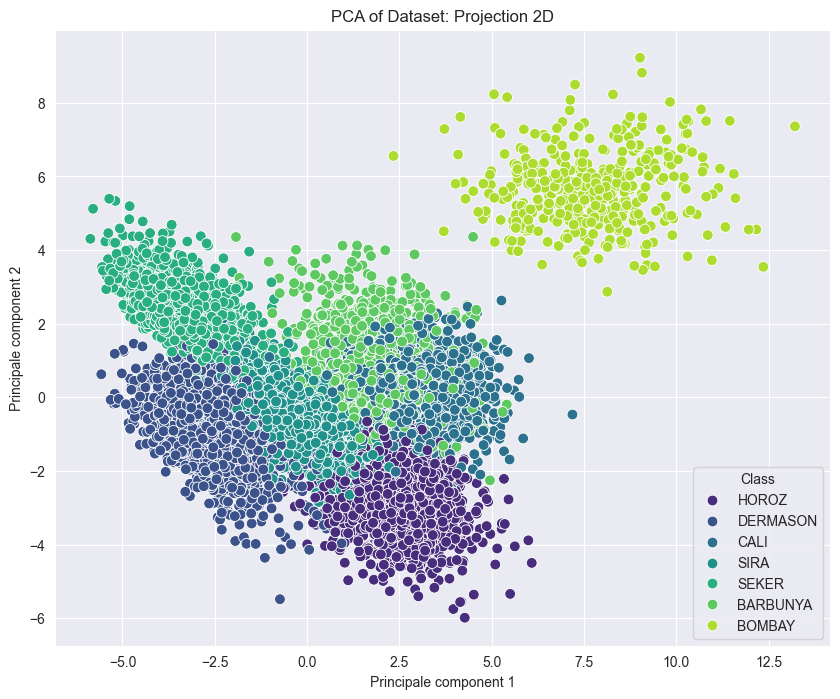

In [35]:
# Plotting the data to see clustering based on the two PCs
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.scatterplot(x='PC1', y='PC2', hue='Class', data=df_pca, palette='viridis', s=60)
plt.title('PCA of Dataset: Projection 2D')
plt.xlabel('Principale component 1')
plt.ylabel('Principale component 2')

plt.show()

In [36]:
# Printing the variance of the two PCs components, inorder to
# determinate the total amount of maintained information
variance = pca.explained_variance_ratio_

print(f"PC1 explains: {variance[0]*100:.2f}% of variance")
print(f"PC2 explains: {variance[1]*100:.2f}% of variance")
print(f"Total amount of maintained information: {sum(variance)*100:.2f}%")

PC1 explains: 55.30% of variance
PC2 explains: 26.55% of variance
Total amount of maintained information: 81.84%


In [37]:
# How many PCs do we need for maintain the 95% of information?
pca_95 = PCA(n_components=0.95)
X_train_pca_95 = pca_95.fit_transform(X_train)

print(f"Number of components required for 95% variance: {pca_95.n_components_}")

Number of components required for 95% variance: 5


### Comments
Having 81.84% of the information concentrated in just two dimensions is very fortunate.

1. Reliability of the 2D graph: Since the first two components explain almost 82% of the variance, the scatter plot you generated earlier is a very accurate representation of reality.

2. Data Redundancy: The fact that we only need 5 components (out of about 16 original ones) to cover 95% of the information means that our original features are highly correlated with each other. We have a lot of “repetitive” data. This is great for Machine Learning models, which will suffer less from the “curse of dimensionality”.


Top 5 feature for PC1:
MajorAxisLength    0.325858
ShapeFactor2       0.315189
Perimeter          0.310978
EquivDiameter      0.297519
ConvexArea         0.283008
Name: PC1, dtype: float64
Top 5 feature for PC2:
MinorAxisLength    0.343606
ShapeFactor1       0.333219
AspectRation       0.330546
Compactness        0.328929
ShapeFactor3       0.327697
Name: PC2, dtype: float64


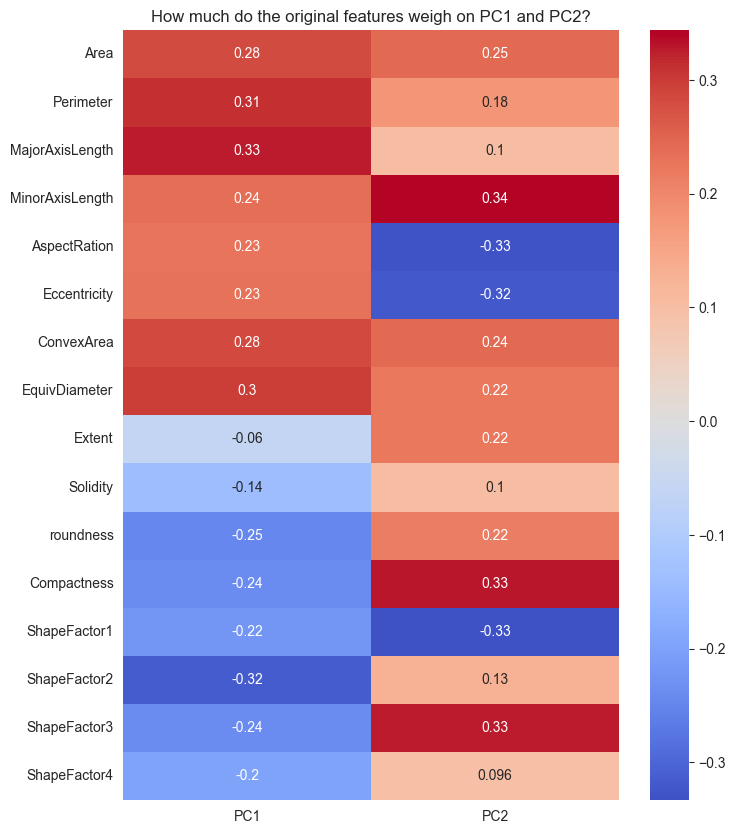

In [38]:
# Searching the top five features for PC1 and PC2
features_names = colum_names[:-1]

# data frame for store all the features, group by PCs
df_loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features_names
)

# The top five features for PC1
print("Top 5 feature for PC1:")
print(df_loadings['PC1'].abs().sort_values(ascending=False).head(5))

# The top five features for PC2
print("Top 5 feature for PC2:")
print(df_loadings['PC2'].abs().sort_values(ascending=False).head(5))

# Heatmap for graphically see the results
plt.figure(figsize=(8,10))
sns.heatmap(df_loadings, annot=True, cmap='coolwarm', center=0)
plt.title('How much do the original features weigh on PC1 and PC2?')
plt.show()

### Comments
It can be seen that the factors dominating PC1 relate to size; this means that if we move along X (in the PCA graph), we will notice that the beans will change from small to large.

The features that dominate PC2, on the other hand, reflect the shape factor. This means that PC2 measures the geometry of the object. Moving along Y, therefore, we would see the beans change shape.

## K-Nearest Neighbors Classification 

Implement the KNN algorithm for classification.

In [39]:
from scipy.stats import mode # for compute the mode
from tqdm.notebook import tqdm # for visualize progress bar

############################
# Class for KNN algorithm #
############################
class K_Nearest_Neighbors_Classifier():
    """
    This class implements the K Nearest Neighbors Classifier algorithm. It contains all the functions needed for the scope.
    Functions:
    - fit(X_train, y_train): Function to store the training set
    - predict(X_test): It's the main function, in which is computing the searching of the KNNs
    - find_neighbors(x): It's a helper function, used in predict(X_test), to find the neighbor for the current point.
    - euclidean(x): Helper function to calculate Euclidean distance for the current point. It's used inside find_neighbors(x).

    """

    # hyperparameter K (number of neighbors)
    def __init__(self, K):
        self.K = K


    ##################################
    # Function to store training set #
    ##################################
    def fit(self, X_train, y_train):

        self.X_train = X_train

        self.y_train = y_train

        # nr of training examples, nr of features
        self.m, self.n = X_train.shape


    ###########################
    # Function for prediction #
    ###########################
    def predict(self, X_test):

        self.X_test = X_test

        # nr of test examples, nr of features
        self.m_test, self.n = X_test.shape

        # init of y_predict, vector of zeros
        y_predict = np.zeros(self.m_test)

        # loop on the rows, on the points, to find the KNNs
        for i in tqdm(range(self.m_test), desc="Classifying"):

            x = self.X_test[i]

            # Find the kNN from the current test example
            # init of neighbors' vector of len K
            neighbors = np.zeros(self.K)
            neighbors = self.find_neighbors(x)

            # save the most frequent class in kNN
            mode_result = mode(neighbors)

            # Consistency chek:
            # if the result is a single value return it
            # else return the first
            if np.isscalar(mode_result.mode):
                y_predict[i] = mode_result.mode
            else:
                y_predict[i] = mode_result.mode[0]


        return y_predict


    ####################################################
    # Function to find the KNN to current test example #
    ####################################################
    def find_neighbors(self, x):
        # calculate all Euclidean distances between current
        # test example x and training set X_train

        # array of distances
        euclidean_distances = np.zeros(self.m)

        # we use our function to compute the Euclidean distance,
        # and we store the result for each row
        for i in range(self.m):
            d = self.euclidean(x, self.X_train[i])
            euclidean_distances[i] = d

        # sort y_train according to the euclidean_distance array
        # and store into y_train_sorted
        inds = euclidean_distances.argsort()

        y_train_sorted = self.y_train[inds]

        return y_train_sorted[:self.K]


    ############################################
    # Function to calculate Euclidean distance #
    ############################################
    def euclidean(self, x, x_train):
        return np.sqrt(np.sum(np.square(x - x_train)))


###############
# Driver code #
###############
def main():

    # Model Training, we use K=5
    model = K_Nearest_Neighbors_Classifier(K = 5)

    model.fit(X_train, y_train)

    # Prediction on test
    y_pred = model.predict(X_test)

    # Measure performance, values used to compute the accuracy
    correctly_classified = 0
    count = 0

    # loop on y_pred
    for count in range(np.size(y_pred)):
        # if the prediction is correct, increase the counter
        if y_test[count] == y_pred[count]:
            correctly_classified += 1

        count += 1

    # Compute and print the accuracy
    print(f"Accuracy on test set: {(correctly_classified/count)*100:.2f}%")

# Main
if __name__ == "__main__":

    main()

Classifying:   0%|          | 0/3403 [00:00<?, ?it/s]

Accuracy on test set: 92.27%


In [40]:
###################
# Using after PCA #
###################
X_test_pca = pca.transform(X_test)

###############
# Driver code #
###############

def main():

    # Model Training
    model = K_Nearest_Neighbors_Classifier(K = 5)

    model.fit(X_train_pca, y_train)

    # Prediction on test
    y_pred = model.predict(X_test_pca)

    # Measure performance, values used to compute the accuracy
    correctly_classified = 0
    count = 0

    # loop on y_pred
    for count in range(np.size(y_pred)):
        # if the prediction is correct, increase the counter
        if y_test[count] == y_pred[count]:
            correctly_classified += 1

        count += 1

    # Compute and print the accuracy
    print(f"Accuracy on test set: {(correctly_classified/count)*100:.2f}%")

# Main
if __name__ == "__main__":

    main()

Classifying:   0%|          | 0/3403 [00:00<?, ?it/s]

Accuracy on test set: 85.13%


## Decision Trees with Numerical Features 

Modify the implementation of decision trees to account for numerical input features.

In [41]:
#########################################################################################
# Class Node with attributes for a threshold, right and left nodes, value for the split #
#########################################################################################
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    # Helper function to determinate if a node is a leaf
    def is_leaf(self):
        return self.value is not None

In [42]:
###########################
# Class for ID3 algorithm #
###########################
class DecisionTree:
    """
    This class is the implementation of Decision Tree algorithm for Numerical features.
    Functions:
    - _is_finished(depth): Helper. It takes the current depth and cheks if one or more conditions for stopping the algorithm are reached.
    - _entropy(y): Helper. Calculates the entropy.
    - _create_split(X, thresh): Helper. Function that creates the split returns the left and right indexes for the split of the data frame.
    - _information_gain(X, y, thresh): Helper. Function that calculates the information gain using _entrpy an _create_split.
    - _best_split(X, y, features): Helper. Function that chooses the best split at each step according to the IG.
    - _build_tree(X, y, depth=0): Helper. Recursive. Function used to build the tree. It uses _is_finished, _create_split, _best_split.
    - _traverse_tree(x, node): Helper. Recursive. Function that travers the tree, used in training.
    - fit(X, y): Function to store the training test and build the tree, using _build_tree.
    - predict(x): Function to predict the class of the test set points, using _traverse_tree.

    """

    # Initialization with limits for tree depth and number of children for each parent
    def __init__(self, max_depth=100, min_samples_split=2):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None


    # Helper function, it checks if the depth condition or number of classes condition or number of samples conditions is verified
    def _is_finished(self, depth):

        if (depth >= self.max_depth
        or self.n_class_labels == 1
        or self.n_samples < self.min_samples_split):
            return True
        return False


    # Helper function that computes the entropy
    def _entropy(self, y):

        labels, counts = np.unique(y, return_counts=True)
        proportions = counts / len(y)
        entropy = -np.sum([p * np.log2(p) for p in proportions if p > 0])
        return entropy


    # Helper function that creates the split returns the left and right indexes for the split of the data frame
    def _create_split(self, X, thresh):

        left_idx = np.argwhere(X <= thresh).flatten()
        right_idx = np.argwhere(X > thresh).flatten()

        return left_idx, right_idx


    # Helper function that calculates the information gain using _entrpy an _create_split
    def _information_gain(self, X, y, thresh):

        # Compute the parent loss
        parent_loss = self._entropy(y)
        left_idx, right_idx = self._create_split(X, thresh)
        n, n_left, n_right = len(y), len(left_idx), len(right_idx)

        if n_left == 0 or n_right == 0:
            return 0

        # Compute the child loss
        child_loss = (n_left / n)*self._entropy(y[left_idx]) + (n_right / n)*self._entropy(y[right_idx])

        # Compute the information gain
        return parent_loss - child_loss


    # Helper for choose the best split at each step according to the IG
    def _best_split(self, X, y, features):

        # Initialize a dictionary
        split = {'score':-1, 'feat': None, 'thresh': None}

        # Fore each feature in all the features
        for feat in features:
            X_feat = X[:, feat]
            unique_values = np.unique(X_feat)

            # if the number of features is greater than 100, use percentiles for thresholds
            # else use unique values
            if len(unique_values) > 100:
                percentiles = np.linspace(0, 100, 11)
                thresholds = np.percentile(X_feat, percentiles)
            else:
                thresholds = unique_values

            # for each threshold in all the thresholds
            for thresh in thresholds:
                # Compute the score
                score = self._information_gain(X_feat, y, thresh)

                # if the current score is greater than the previous, swap it
                if score > split['score']:
                    split['score'] = score
                    split['feat'] = feat
                    split['thresh'] = thresh

        return split['feat'], split['thresh']


    # Helper recursive function used to build the tree. It uses _is_finished, _create_split, _best_split.
    def _build_tree(self, X, y, depth=0):
        self.n_samples, self.n_features = X.shape
        self.n_class_labels = len(np.unique(y))

        # stopping criteria
        if self._is_finished(depth):
            most_common_label = np.argmax(np.bincount(y.astype(int)))
            return Node(value=most_common_label)

        # get the best split
        rnd_feats = np.random.choice(self.n_features, self.n_features, replace=False)
        best_feat, best_thresh = self._best_split(X, y, rnd_feats)

        # grow children recursively
        left_idx, right_idx = self._create_split(X[:, best_feat], best_thresh)

        # sanity check
        if len(left_idx) == 0 or len(right_idx) == 0:
            most_common_label = np.argmax(np.bincount(y.astype(int)))
            return Node(value=most_common_label)

        # Recursive on the children
        left_child = self._build_tree(X[left_idx, :], y[left_idx], depth + 1)
        right_child = self._build_tree(X[right_idx, :], y[right_idx], depth + 1)

        return Node(best_feat, best_thresh, left_child, right_child)


    # Helper recursive function, to travers the tree, used in training.
    def _traverse_tree(self, x, node):

        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)

        return self._traverse_tree(x, node.right)


    # Function to store the training test and build the tree, using _build_tree
    def fit(self, X, y):
        # sanity check
        y = y.astype(int).ravel()

        self.root = self._build_tree(X,y)


    # Function to predict the class of the test set points, using _traverse_tree
    def predict(self, X):

        predictions = [self._traverse_tree(x, self.root) for x in X]

        return  np.array(predictions)

In [43]:
# We use a max depth of 10 nodes
clf = DecisionTree(max_depth=10)

print("Start training...")
clf.fit(X_train, y_train)
print("Training finished!")

y_pred = clf.predict(X_test)

# flatting the label arrays
y_test_flat = y_test.ravel()
y_pred_flat = y_pred.ravel()

# Function to compute the accuracy
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

acc = accuracy(y_test_flat, y_pred_flat)

print(f"Accuracy: {acc*100:.2f}%")

Start training...
Training finished!
Accuracy: 90.07%


## Gaussian Naive Bayes 
Modufy the implemntation of naive Bayes to accout for numerical input features. The likelihood of each class ($p(data|class)$) is assumed to be a Gaussian $\frac{1}{\sqrt(\sigma^2 2 \pi)} \exp (\frac{1}{2} \frac{(x-\mu)}{\sigma^2})$, where $\mu, \sigma^2$ are the mean and the variance for each class;

In [44]:
############################################
# Class for Gaussian Naive Bayes algorithm #
############################################
class Gaussian_Naive_Bayes:

    def __init__(self):
        pass


    # Function to store the training test and compute mean, variance and prior
    def fit(self, X, y):
        n_samples, n_features = X.shape
        y = y.ravel() # flatting the ys
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # Initializing matrix for store results
        # Mean and variance: 1 row for each class, 1 colum for each feature
        self._mean = np.zeros((n_classes, n_features))
        self._var = np.zeros((n_classes, n_features))
        self._priors = np.zeros(n_classes)

        # loop that calculates mean, variance and prior,
        # and stores them into the respective matrix
        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self._mean[idx, :] = np.mean(X_c, axis=0)
            self._var[idx, :] = np.var(X_c, axis=0)
            self._priors[idx] = X_c.shape[0] / n_samples


    # Helper that calculates the log of the pdf
    def _log_pdf(self, class_idx, x):
        mean = self._mean[class_idx]
        var = self._var[class_idx]

        return (-(1/2)*np.log(2*np.pi*var)) - (((x-mean)**2)/(2*var))


    # Helper that calculates the best class, using posterior, for the current data point
    def _predict(self, x):
        posteriors = []

        # calculate the posterior for the current data point for each class
        for idx, c in enumerate(self.classes):
            prior = np.log(self._priors[idx])
            likelihood = np.sum(self._log_pdf(idx, x))
            posteriors.append(likelihood+prior)

        # save the index of the best class
        best_class_idx = np.argmax(posteriors)

        return self.classes[best_class_idx]


    # Make the prediction
    def predict(self, X):
        predictions = []

        # For each point call the _predict helper and calculate the best class
        for i in range(X.shape[0]):
            pred = self._predict(X[i, :])
            predictions.append(pred)

        # transform to a numpy array
        np_predictions = np.array(predictions)
        return np_predictions

###############
# Driver code #
###############
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def main():
    # Model Training

    model = Gaussian_Naive_Bayes()

    model.fit(X_train, y_train)

    # Prediction on test

    print("Start training...")
    model.fit(X_train, y_train)
    print("Training finished!")

    y_pred = model.predict(X_test)

    y_test_flat = y_test.ravel()
    y_pred_flat = y_pred.ravel()


    print(f"Accuracy: {accuracy(y_test_flat, y_pred_flat)*100:.2f}%")


if __name__ == "__main__":
    main()

Start training...
Training finished!
Accuracy: 89.51%
